In [ ]:
# ===============================================================
# ETAPA 1: Instalación de librerías y configuración inicial
# ===============================================================

# !pip install pandas numpy scikit-learn matplotlib seaborn tensorflow joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib


In [ ]:
# ===============================================================
# ETAPA 2: Cargar dataset BEED desde un único archivo CSV
# ===============================================================

# Ruta del archivo CSV
base_datos = pd.read_csv('/content/BEED_Data.csv')
print(" Datos cargados correctamente")


 Datos cargados correctamente


Forma del DataFrame: (8000, 17)

Distribución de clases (y):
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64
Verificación de duplicados:
No se encontraron duplicados en el dataset.


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
count,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,-1.490375,-2.189375,-3.23750,-4.119375,-1.821625,-2.311750,-3.398125,-3.448625,-1.647875,-2.56125,-3.524500,-4.782750,-2.164000,-2.910875,-4.355375,-4.113750,1.500000
std,36.824213,36.108088,35.80249,36.285268,37.621284,36.306006,36.358395,36.522214,38.107721,37.54068,37.343938,37.469582,38.144075,36.640555,36.242793,35.933601,1.118104
min,-281.000000,-255.000000,-255.00000,-257.000000,-264.000000,-277.000000,-277.000000,-260.000000,-290.000000,-302.00000,-276.000000,-306.000000,-288.000000,-290.000000,-323.000000,-317.000000,0.000000
25%,-7.000000,-7.000000,-7.00000,-10.000000,-10.000000,-8.000000,-8.000000,-7.000000,-7.000000,-8.00000,-8.000000,-11.000000,-10.000000,-8.000000,-9.000000,-6.000000,0.750000
50%,0.000000,0.000000,-1.00000,-1.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.00000,-1.000000,-2.000000,0.000000,0.000000,-2.000000,-1.000000,1.500000
75%,8.000000,8.000000,5.00000,7.000000,10.000000,8.000000,6.000000,5.000000,8.000000,8.00000,5.000000,7.000000,10.000000,9.000000,5.000000,4.000000,2.250000
max,252.000000,261.000000,238.00000,246.000000,249.000000,245.000000,220.000000,271.000000,280.000000,251.00000,262.000000,283.000000,296.000000,291.000000,251.000000,270.000000,3.000000



Top 10 pares de variables con mayor correlación:
X2 - X3: 0.910
X10 - X11: 0.905
X14 - X15: 0.900
X6 - X7: 0.899
X15 - X16: 0.888
X1 - X2: 0.887
X7 - X8: 0.887
X9 - X10: 0.886
X8 - X9: 0.872
X13 - X14: 0.854


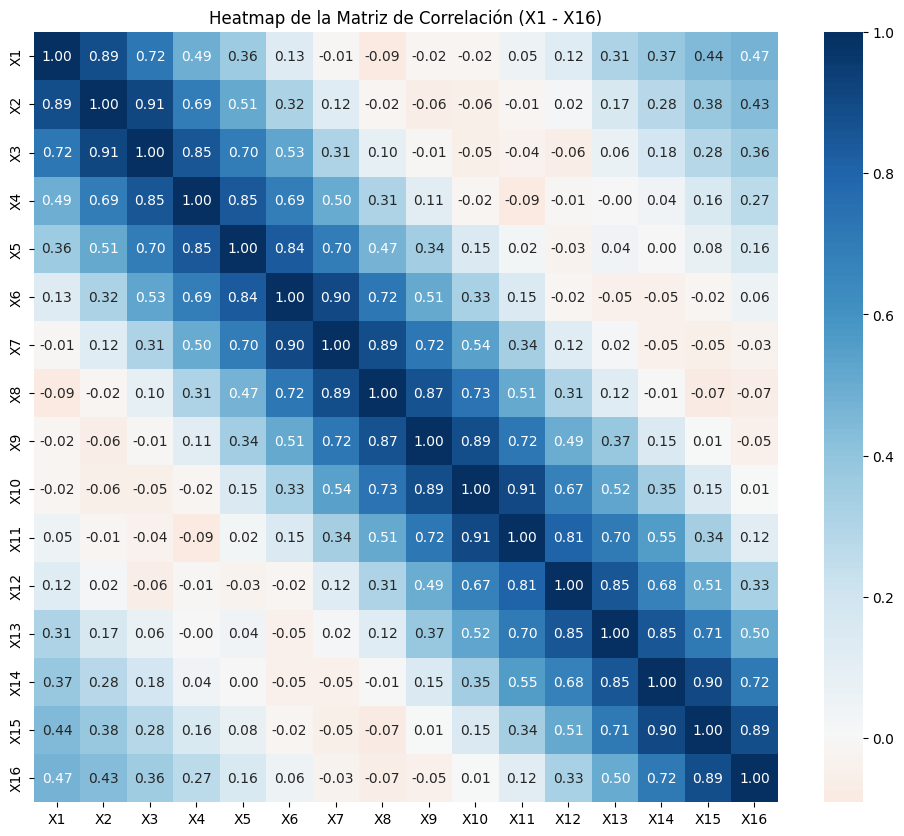

In [ ]:
# ===============================================================
# ETAPA 3: Análisis exploratorio
# ===============================================================
print(f"Forma del DataFrame: {base_datos.shape}")

print("\nDistribución de clases (y):")
print(base_datos['y'].value_counts())

# Verificar si existen duplicados
num_duplicados = base_datos.duplicated().sum()

print("Verificación de duplicados:")
if num_duplicados == 0:
    print("No se encontraron duplicados en el dataset.")
else:
    print(f"Se encontraron {num_duplicados} registros duplicados.")


# Estadísticas descriptivas
display(base_datos.describe(include='all'))

# Calcular matriz de correlación
features = [f'X{i}' for i in range(1, 17)]
data = base_datos[features]
corr_matrix = data.corr()

# Mostrar matriz de correlación con valores
# print("Matriz de correlación:")
# print(corr_matrix)

# Extraer los 10 pares con mayor correlación (excluyendo diagonal)
corr_pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_pairs.append((features[i], features[j], corr_matrix.iloc[i, j]))

# Ordenar por valor absoluto de correlación descendente
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]

print("\nTop 10 pares de variables con mayor correlación:")
for pair in corr_pairs_sorted:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

# Visualizar matriz de correlación con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title('Heatmap de la Matriz de Correlación (X1 - X16)')
plt.show()


In [ ]:
# ===============================================================
# ⚙️ ETAPA 4: Preprocesamiento de datos
# ===============================================================

# Separar variables predictoras y variable objetivo
X = base_datos.drop(columns=['y'])
y = base_datos['y']

# Escalado (normalización)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (6400, 16)
Tamaño prueba: (1600, 16)


=== Resultados Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.97      0.98       400
           2       0.92      0.94      0.93       400
           3       0.94      0.93      0.93       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



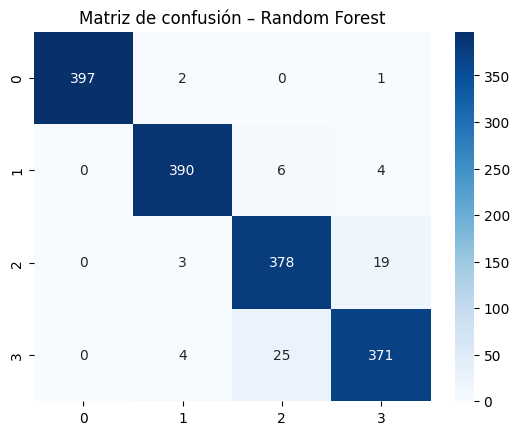

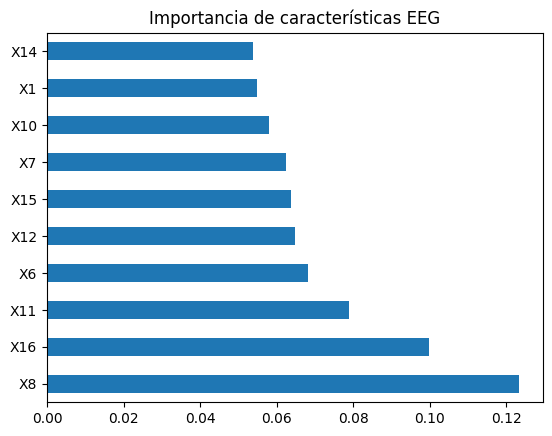

In [ ]:
# ===============================================================
# 🌲 ETAPA 5.1: Entrenamiento con Random Forest
# ===============================================================

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Resultados Random Forest ===")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión – Random Forest")
plt.show()

# Importancia de características
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title("Importancia de características EEG")
plt.show()

In [ ]:
# ===============================================================
# ⚙️ ETAPA 5.2: Modelo SVM (Support Vector Machine)
# ===============================================================

from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=== Resultados SVM ===")
print(classification_report(y_test, y_pred_svm))

=== Resultados SVM ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       400
           1       0.81      0.71      0.76       400
           2       0.57      0.94      0.71       400
           3       0.73      0.35      0.47       400

    accuracy                           0.75      1600
   macro avg       0.78      0.75      0.73      1600
weighted avg       0.78      0.75      0.73      1600



In [ ]:
# ===============================================================
# 🌲 ETAPA 5.3: Extra Trees (variante de Random Forest)
# ===============================================================

from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=200, random_state=42)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print("=== Resultados Extra Trees ===")
print(classification_report(y_test, y_pred_et))

print("=== Resultados Extra Trees ===")
print(classification_report(y_test, y_pred_et))

=== Resultados Extra Trees ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.99      0.98      0.99       400
           2       0.97      0.98      0.98       400
           3       0.98      0.98      0.98       400

    accuracy                           0.98      1600
   macro avg       0.99      0.98      0.99      1600
weighted avg       0.99      0.98      0.99      1600

=== Resultados Extra Trees ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.99      0.98      0.99       400
           2       0.97      0.98      0.98       400
           3       0.98      0.98      0.98       400

    accuracy                           0.98      1600
   macro avg       0.99      0.98      0.99      1600
weighted avg       0.99      0.98      0.99      1600



In [ ]:
# ===============================================================
# ⚡ ETAPA 5.4: Modelo XGBoost
# ===============================================================
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== Resultados XGBoost ===")
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:17:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Resultados XGBoost ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.97      0.94      0.96       400
           2       0.87      0.92      0.89       400
           3       0.88      0.87      0.88       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [ ]:
# ===============================================================
# 🧩 ETAPA 5.5: MLP (Multi-Layer Perceptron)
# ===============================================================

from sklearn.neural_network import MLPClassifier


mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("=== Resultados MLP ===")
print(classification_report(y_test, y_pred_mlp))

=== Resultados MLP ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.98      0.97      0.98       400
           2       0.96      0.97      0.96       400
           3       0.97      0.97      0.97       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



In [ ]:
# ===============================================================
# 🤝 ETAPA 5.6: Voting Classifier (Ensamblado de modelos)
# ===============================================================

from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report

# 1. ENTRENAR EL RANDOM FOREST POR SEPARADO
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)   # ← OBLIGATORIO

# 2. CREAR Y ENTRENAR EL ENSAMBLE
estimators = [
    ('rf', rf),
    ('xgb', xgb_model)
]

voting = VotingClassifier(estimators=estimators, voting='soft')
voting.fit(X_train, y_train)

# 3. PREDICCIÓN DEL ENSAMBLE
y_pred_voting = voting.predict(X_test)

print("=== Resultados Voting Classifier ===")
print(classification_report(y_test, y_pred_voting))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:18:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Resultados Voting Classifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.95      0.97       400
           2       0.92      0.94      0.93       400
           3       0.92      0.92      0.92       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [ ]:
# ===============================================================
# 🤖 ETAPA 5.7: Red neuronal para clasificación multiclase
# ===============================================================


model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')  # 4 clases de salida
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4155 - loss: 1.1867 - val_accuracy: 0.6898 - val_loss: 0.8387
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6827 - loss: 0.8192 - val_accuracy: 0.7414 - val_loss: 0.6353
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7326 - loss: 0.6573 - val_accuracy: 0.7617 - val_loss: 0.5385
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7498 - loss: 0.5762 - val_accuracy: 0.7969 - val_loss: 0.4781
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7725 - loss: 0.5154 - val_accuracy: 0.8227 - val_loss: 0.4308
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8084 - loss: 0.4581 - val_accuracy: 0.8383 - val_loss: 0.3962
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8195 - loss: 0.4461 - val_accuracy: 0.8539 - val_loss: 0.3675
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8162 - loss: 0.4226 - val_accuracy: 0.8641 - val_

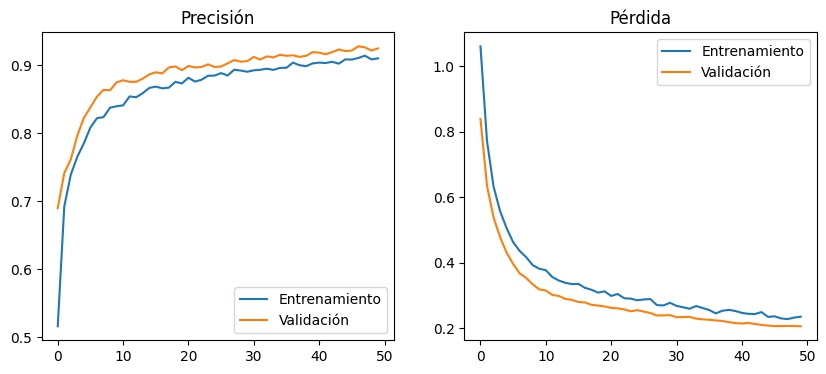

✅ Precisión final del modelo: 0.924


In [ ]:
# ===============================================================
# 📈 ETAPA 7: Evaluación del modelo neuronal
# ===============================================================

# Curvas de precisión y pérdida
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.legend()

plt.show()

# Evaluación final
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Precisión final del modelo: {acc:.3f}")

In [ ]:
# ===============================================================
# 💾 ETAPA 8: Guardar modelos e inferencia
# ===============================================================

# Guardar los modelos entrenados
joblib.dump(rf, "modelo_random_forest_beed.joblib")
model.save("modelo_red_neuronal_beed.h5")

# Ejemplo de predicción con un registro del test
ejemplo = X_test[0].reshape(1, -1)

pred_rf = rf.predict(ejemplo)[0]
pred_dl = np.argmax(model.predict(ejemplo), axis=1)[0]

print(f"Predicción Random Forest: {pred_rf}")
print(f"Predicción Red Neuronal: {pred_dl}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicción Random Forest: 3
Predicción Red Neuronal: 1


Extracción de características lineal: PCA

Dimensiones originales: 16
Dimensiones tras PCA: 6


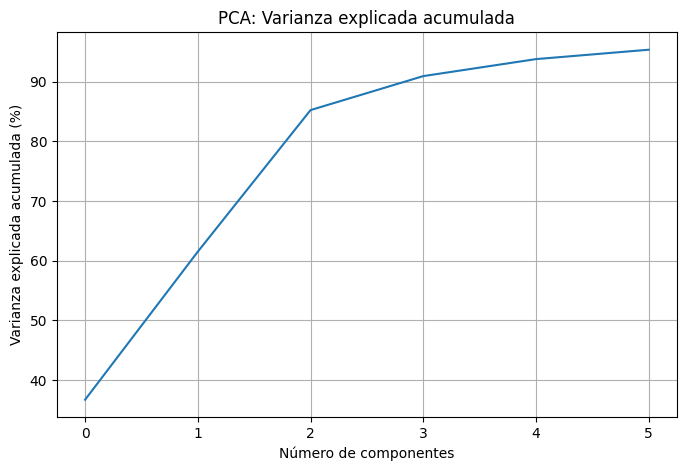

In [ ]:
from sklearn.decomposition import PCA

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: elegir componentes que expliquen al menos 95% de la varianza
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensiones originales: {X.shape[1]}")
print(f"Dimensiones tras PCA: {X_pca.shape[1]}")  # número de componentes seleccionados

# Varianza explicada
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada (%)")
plt.title("PCA: Varianza explicada acumulada")
plt.grid(True)
plt.show()


Extracción de características no lineal: UMAP

In [ ]:
# ===============================================================
# 🔹  Reducción de Dimensión y evaluación individual de modelos
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -------------------------------
# Datos ya escalados (X_scaled, y)
# -------------------------------

# -------------------------------
# 🔹 PCA (6 componentes)
# -------------------------------
n_components_pca = 6
pca = PCA(n_components=n_components_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensiones originales: {X_scaled.shape[1]}")
print(f"Dimensiones tras PCA: {X_pca.shape[1]}")

# -------------------------------
# 🔹 UMAP (8 componentes)
# -------------------------------
n_components_umap = 8
umap_model = umap.UMAP(n_components=n_components_umap, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
print(f"Dimensiones tras UMAP: {X_umap.shape[1]}")

# ===============================================================
# Función para entrenar y evaluar cada modelo
# ===============================================================
def entrenar_evaluar(modelo, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"=== {modelo.__class__.__name__} ===")
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de confusión - {modelo.__class__.__name__}")
    plt.show()

    return acc


Dimensiones originales: 16
Dimensiones tras PCA: 6


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dimensiones tras UMAP: 8


=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.88      0.86      0.87       400
           2       0.78      0.86      0.82       400
           3       0.84      0.76      0.80       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



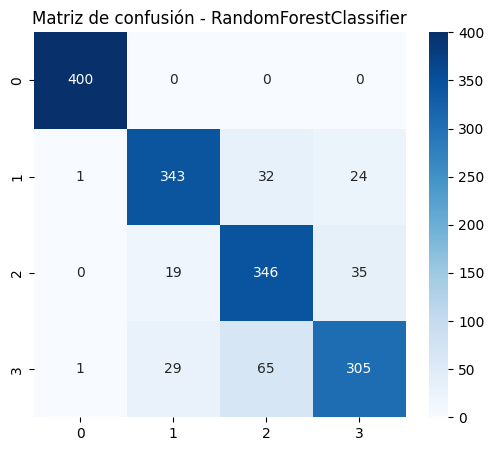

=== SVC ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       400
           1       0.71      0.58      0.64       400
           2       0.48      0.92      0.63       400
           3       0.55      0.16      0.25       400

    accuracy                           0.66      1600
   macro avg       0.68      0.66      0.63      1600
weighted avg       0.68      0.66      0.63      1600



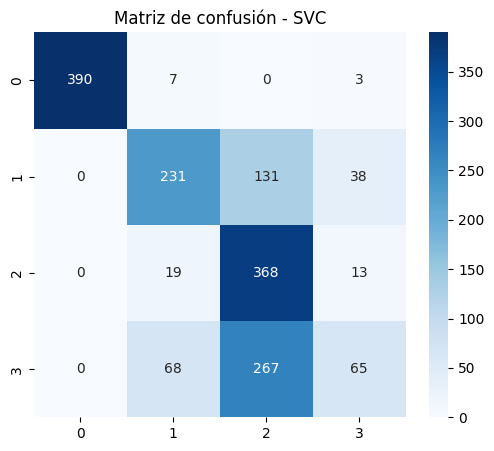

In [ ]:

# ===============================================================
# 🔹 Random Forest PCA
# ===============================================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
acc_rf_pca = entrenar_evaluar(rf, X_pca, y)

# ===============================================================
# 🔹 SVM PCA
# ===============================================================
svm = SVC(kernel='rbf', C=1, probability=True, random_state=42)
acc_svm_pca = entrenar_evaluar(svm, X_pca, y)

=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.96      0.95      0.96       400
           2       0.92      0.95      0.93       400
           3       0.94      0.92      0.93       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



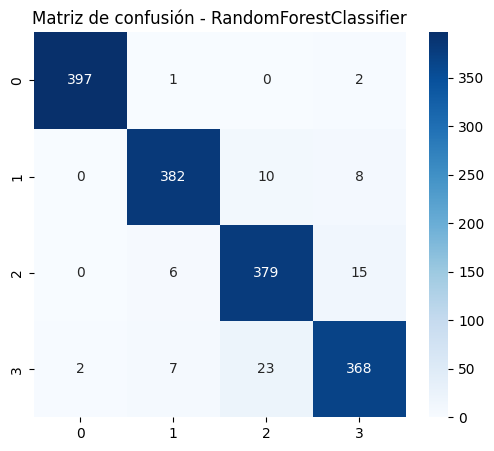

=== SVC ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       400
           1       0.80      0.81      0.80       400
           2       0.72      0.86      0.78       400
           3       0.70      0.55      0.61       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.80      1600
weighted avg       0.80      0.80      0.80      1600



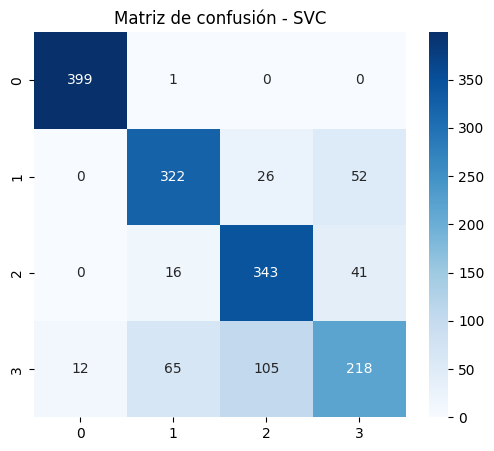


=== Tabla resumen de reducción de dimensión y desempeño ===


,Método,Modelo,Dimensiones originales,Dimensiones reducidas,% Reducción,Accuracy
0,PCA,Random Forest,16,6,62.5,0.87125
1,PCA,SVM,16,6,62.5,0.65875
2,UMAP,Random Forest,16,8,50.0,0.95375
3,UMAP,SVM,16,8,50.0,0.80125


In [ ]:

# ===============================================================
# 🔹 Random Forest UMAP
# ===============================================================
rf_umap = RandomForestClassifier(n_estimators=100, random_state=42)
acc_rf_umap = entrenar_evaluar(rf_umap, X_umap, y)

# ===============================================================
# 🔹 SVM UMAP
# ===============================================================
svm_umap = SVC(kernel='rbf', C=1, probability=True, random_state=42)
acc_svm_umap = entrenar_evaluar(svm_umap, X_umap, y)

# ===============================================================
# 🔹 Tabla resumen de desempeño y reducción
# ===============================================================
tabla_resumen = pd.DataFrame({
    "Método": ["PCA", "PCA", "UMAP", "UMAP"],
    "Modelo": ["Random Forest", "SVM", "Random Forest", "SVM"],
    "Dimensiones originales": X_scaled.shape[1],
    "Dimensiones reducidas": [X_pca.shape[1], X_pca.shape[1], X_umap.shape[1], X_umap.shape[1]],
    "% Reducción": [
        100*(X_scaled.shape[1]-X_pca.shape[1])/X_scaled.shape[1],
        100*(X_scaled.shape[1]-X_pca.shape[1])/X_scaled.shape[1],
        100*(X_scaled.shape[1]-X_umap.shape[1])/X_scaled.shape[1],
        100*(X_scaled.shape[1]-X_umap.shape[1])/X_scaled.shape[1]
    ],
    "Accuracy": [acc_rf_pca, acc_svm_pca, acc_rf_umap, acc_svm_umap]
})

print("\n=== Tabla resumen de reducción de dimensión y desempeño ===")
display(tabla_resumen)

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


--- Modelo PCA: Random Forest ---
=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.88      0.86      0.87       400
           2       0.78      0.86      0.82       400
           3       0.84      0.76      0.80       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



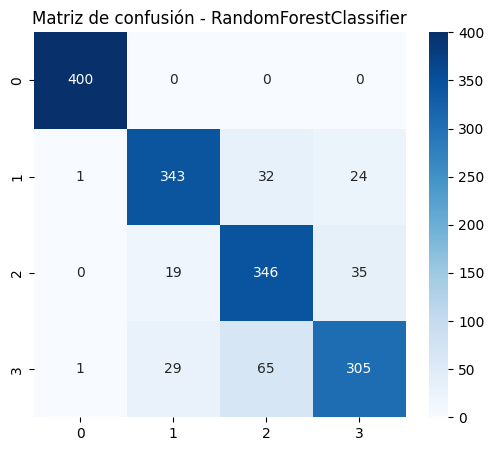


--- Modelo PCA: SVM ---
=== SVC ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       400
           1       0.71      0.58      0.64       400
           2       0.48      0.92      0.63       400
           3       0.55      0.16      0.25       400

    accuracy                           0.66      1600
   macro avg       0.68      0.66      0.63      1600
weighted avg       0.68      0.66      0.63      1600



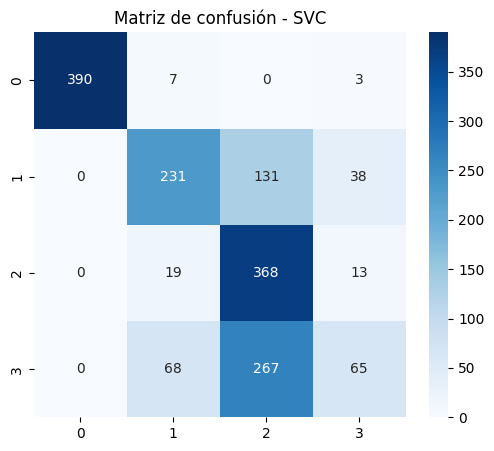


--- Modelo PCA: Extra Trees ---
=== ExtraTreesClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.91      0.86      0.89       400
           2       0.78      0.89      0.84       400
           3       0.85      0.78      0.81       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



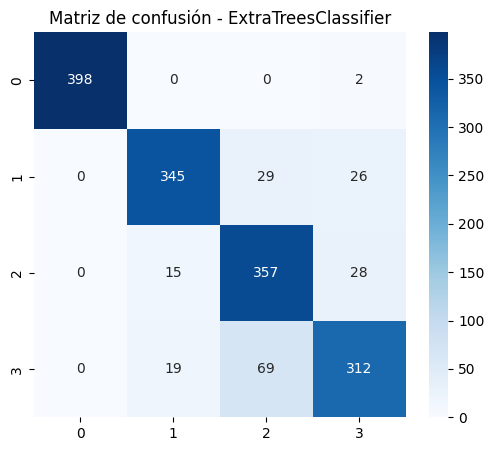


--- Modelo PCA: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:20:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.88      0.85      0.87       400
           2       0.74      0.83      0.78       400
           3       0.79      0.72      0.75       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.85      1600
weighted avg       0.85      0.85      0.85      1600



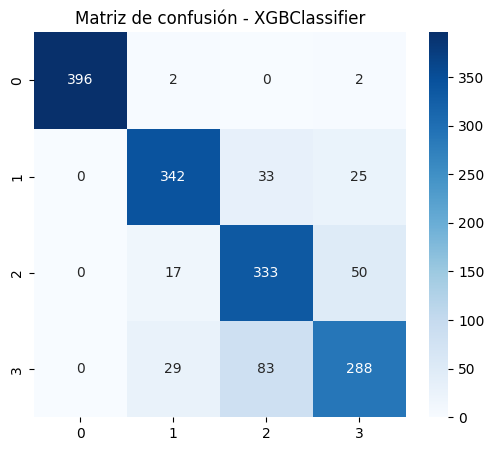


--- Modelo PCA: kNN ---
=== KNeighborsClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       400
           1       0.85      0.83      0.84       400
           2       0.77      0.84      0.80       400
           3       0.76      0.73      0.75       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600



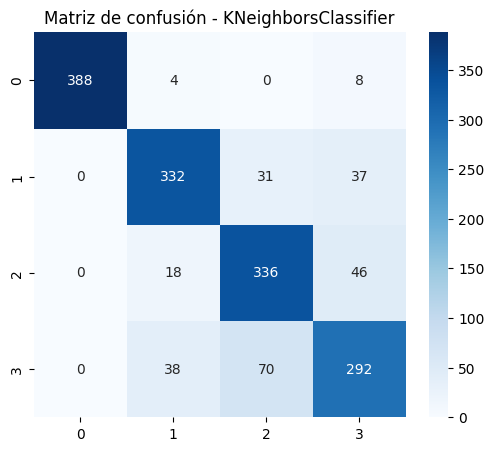


--- Modelo PCA: Logistic Regression ---
=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.75      0.50      0.60       400
           1       0.40      0.47      0.43       400
           2       0.40      0.49      0.44       400
           3       0.36      0.33      0.35       400

    accuracy                           0.45      1600
   macro avg       0.48      0.45      0.45      1600
weighted avg       0.48      0.45      0.45      1600



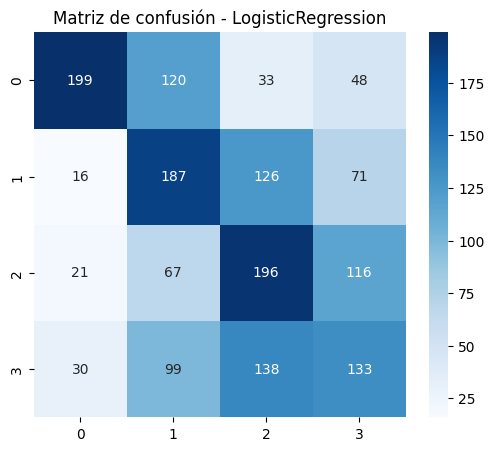


--- Modelo PCA: Voting Classifier ---
=== VotingClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.88      0.86      0.87       400
           2       0.77      0.85      0.81       400
           3       0.81      0.74      0.78       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



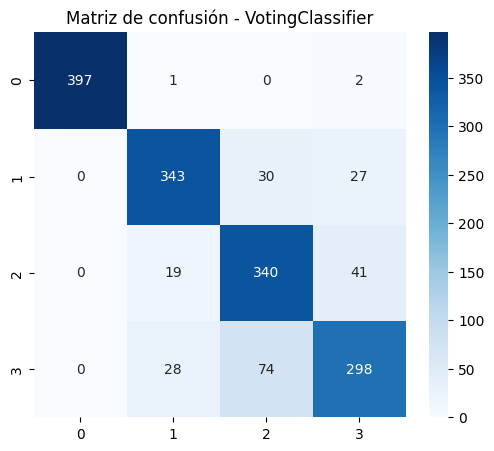

In [ ]:
# ===============================================================
# 🔹 MODELOS SCALERS PCA
# ===============================================================
models_pca = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, probability=True, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# ===============================================================
# 🔹 ENTRENAMIENTO Y EVALUACIÓN PCA
# ===============================================================
results_pca = {}
for name, model in models_pca.items():
    print(f"\n--- Modelo PCA: {name} ---")
    results_pca[name] = entrenar_evaluar(model, X_pca, y)

# ===============================================================
# 🤝 ENSAMBLE VotingClassifier PARA PCA
# ===============================================================
from sklearn.ensemble import VotingClassifier

voting_pca = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=200, eval_metric='mlogloss', random_state=42))
    ],
    voting='soft'
)

print("\n--- Modelo PCA: Voting Classifier ---")
acc_voting_pca = entrenar_evaluar(voting_pca, X_pca, y)



--- Modelo UMAP: Random Forest ---
=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.96      0.95      0.96       400
           2       0.92      0.95      0.93       400
           3       0.94      0.92      0.93       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



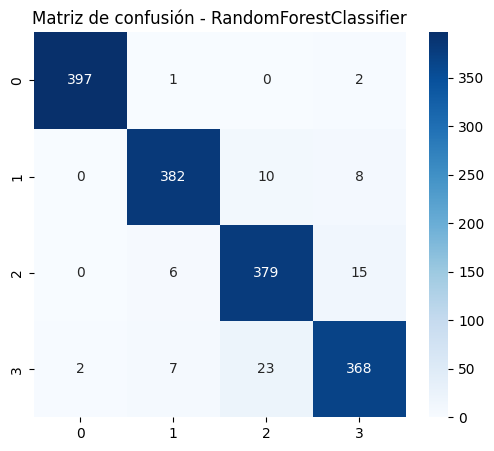


--- Modelo UMAP: SVM ---
=== SVC ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       400
           1       0.80      0.81      0.80       400
           2       0.72      0.86      0.78       400
           3       0.70      0.55      0.61       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.80      1600
weighted avg       0.80      0.80      0.80      1600



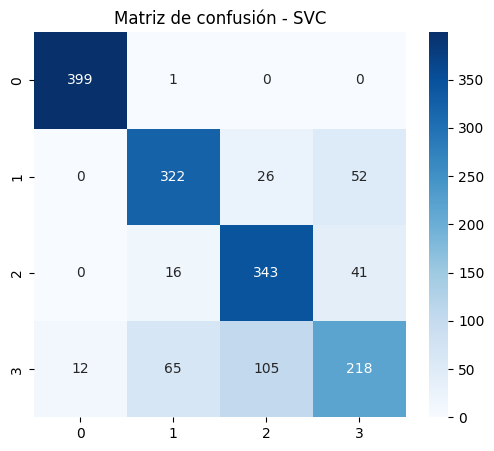


--- Modelo UMAP: Extra Trees ---
=== ExtraTreesClassifier ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.97      0.96      0.97       400
           2       0.94      0.96      0.95       400
           3       0.95      0.93      0.94       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



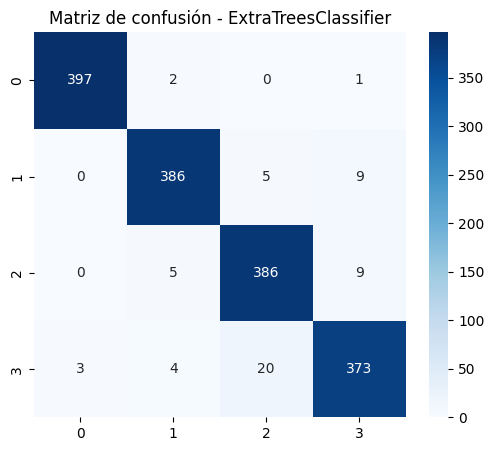


--- Modelo UMAP: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:21:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.96      0.94      0.95       400
           2       0.92      0.94      0.93       400
           3       0.91      0.92      0.92       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



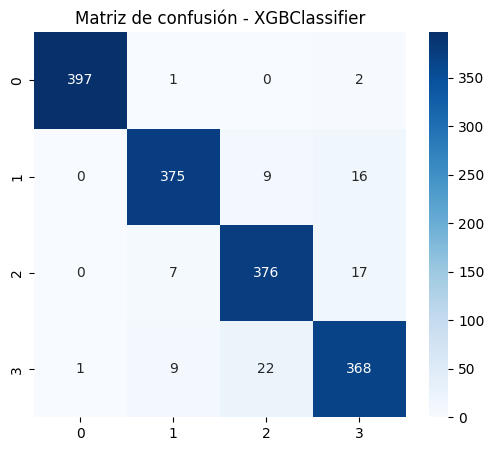


--- Modelo UMAP: kNN ---
=== KNeighborsClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.92      0.91      0.92       400
           2       0.89      0.93      0.91       400
           3       0.91      0.89      0.90       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



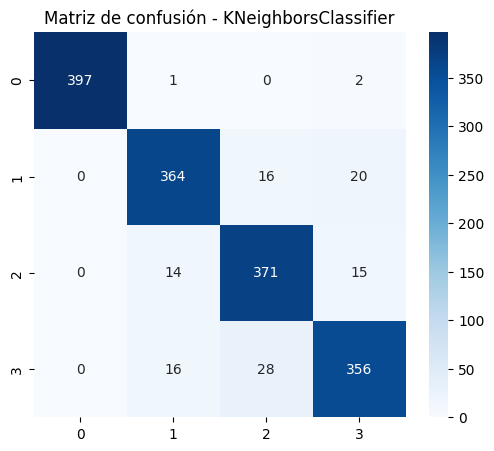


--- Modelo UMAP: Logistic Regression ---
=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       400
           1       0.78      0.78      0.78       400
           2       0.73      0.83      0.78       400
           3       0.67      0.56      0.61       400

    accuracy                           0.79      1600
   macro avg       0.79      0.79      0.79      1600
weighted avg       0.79      0.79      0.79      1600



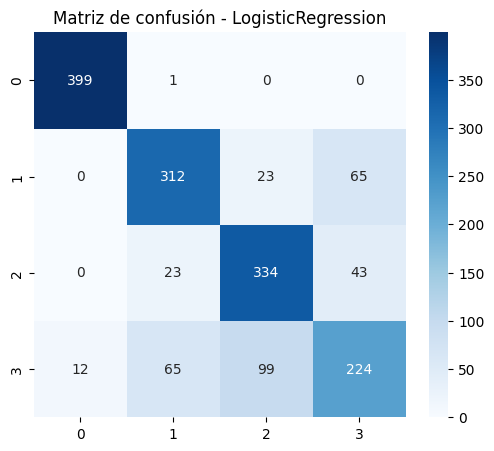

In [ ]:

# ===============================================================
# 🔹 MODELOS SCALERS UMAP
# ===============================================================
models_umap = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, probability=True, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# Entrenamiento y evaluación UMAP
results_umap = {}
for name, model in models_umap.items():
    print(f"\n--- Modelo UMAP: {name} ---")
    results_umap[name] = entrenar_evaluar(model, X_umap, y)

In [ ]:

# ===============================================================
# 🔹 Red neuronal (MLP) para clasificación multiclase con PCA
# ===============================================================
y_cat = to_categorical(y)  # Convertir etiquetas a one-hot
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_cat, test_size=0.2, random_state=42, stratify=y)

mlp_pca = Sequential([
    Dense(64, activation='relu', input_shape=(X_pca.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(y_cat.shape[1], activation='softmax')
])
mlp_pca.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_pca.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
loss, acc_mlp_pca = mlp_pca.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy MLP PCA: {acc_mlp_pca:.4f}")

# 🔹 Red neuronal (MLP) para UMAP
X_train, X_test, y_train, y_test = train_test_split(X_umap, y_cat, test_size=0.2, random_state=42, stratify=y)
mlp_umap = Sequential([
    Dense(64, activation='relu', input_shape=(X_umap.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(y_cat.shape[1], activation='softmax')
])
mlp_umap.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_umap.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
loss, acc_mlp_umap = mlp_umap.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy MLP UMAP: {acc_mlp_umap:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy MLP PCA: 0.7850


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy MLP UMAP: 0.8500


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:22:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== VotingClassifier ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.96      0.94      0.95       400
           2       0.91      0.95      0.93       400
           3       0.93      0.91      0.92       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



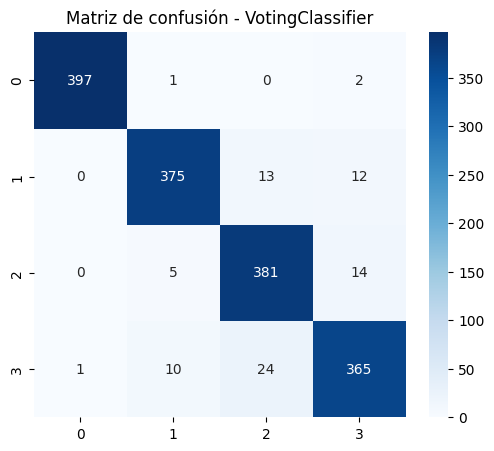

In [ ]:
# ===============================================================
# 🔹 Voting Classifier (ensemble) con UMAP
# ===============================================================
voting_umap = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svc', SVC(kernel='rbf', C=1, probability=True, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42))
    ],
    voting='soft'
)
acc_voting_umap = entrenar_evaluar(voting_umap, X_umap, y)

In [ ]:
# ===============================================================
# 🔹 Tabla resumen de desempeño y reducción
# ===============================================================
tabla_final = pd.DataFrame({
    "Modelo": [
        *list(results_pca.keys()), "MLP PCA", "Voting PCA",
        *list(results_umap.keys()), "MLP UMAP", "Voting UMAP"
    ],
    "Metodo_Reduccion": ["PCA"]*8 + ["UMAP"]*8,
    "Dimensiones_Originales": X_scaled.shape[1],
    "Dimensiones_Reducidas": [X_pca.shape[1]]*8 + [X_umap.shape[1]]*8,
    "%_Reduccion": [
        100*(X_scaled.shape[1]-X_pca.shape[1])/X_scaled.shape[1]]*8 + [100*(X_scaled.shape[1]-X_umap.shape[1])/X_scaled.shape[1]]*8,
    "Accuracy": [
        *list(results_pca.values()), acc_mlp_pca, acc_voting_pca,
        *list(results_umap.values()), acc_mlp_umap, acc_voting_umap
    ]
})

print("\n=== Tabla final de desempeño y reducción de dimensión ===")
display(tabla_final)


=== Tabla final de desempeño y reducción de dimensión ===


,Modelo,Metodo_Reduccion,Dimensiones_Originales,Dimensiones_Reducidas,%_Reduccion,Accuracy
0,Random Forest,PCA,16,6,62.5,0.871250
1,SVM,PCA,16,6,62.5,0.658750
2,Extra Trees,PCA,16,6,62.5,0.882500
3,XGBoost,PCA,16,6,62.5,0.849375
4,kNN,PCA,16,6,62.5,0.842500
5,Logistic Regression,PCA,16,6,62.5,0.446875
6,MLP PCA,PCA,16,6,62.5,0.785000
7,Voting PCA,PCA,16,6,62.5,0.861250
8,Random Forest,UMAP,16,8,50.0,0.953750
9,SVM,UMAP,16,8,50.0,0.801250


In [ ]:
from sklearn.decomposition import PCA
import umap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# 1️⃣ Extracción de características
# ---------------------------------------------------------------

# PCA (6 componentes)
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# UMAP (8 componentes)
umap_model = umap.UMAP(n_components=8, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# ---------------------------------------------------------------
# 2️⃣ División en entrenamiento y prueba
# ---------------------------------------------------------------

# PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# UMAP
X_train_umap, X_test_umap, y_train_umap, y_test_umap = train_test_split(
    X_umap, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------------
# 3️⃣ Definición de modelos
# ---------------------------------------------------------------

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, probability=True, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

# Voting Classifier combinando algunos modelos
voting = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('mlp', models['MLP'])
    ],
    voting='soft'
)
models["Voting Classifier"] = voting

# ---------------------------------------------------------------
# 4️⃣ Función de evaluación completa
# ---------------------------------------------------------------

def evaluate_model(model, X_train, X_test, y_train, y_test, method_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n=== {method_name} ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(cm)

    # ROC-AUC multiclase
    y_bin = label_binarize(y_test, classes=[0,1,2,3])
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    plt.figure(figsize=(6,5))
    for i in range(y_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Clase {i} (AUC={roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curves - {method_name}')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.show()

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



=== Random Forest (PCA) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.88      0.86      0.87       400
           2       0.78      0.86      0.82       400
           3       0.84      0.76      0.80       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600

Confusion Matrix:
[[400   0   0   0]
 [  1 343  32  24]
 [  0  19 346  35]
 [  1  29  65 305]]


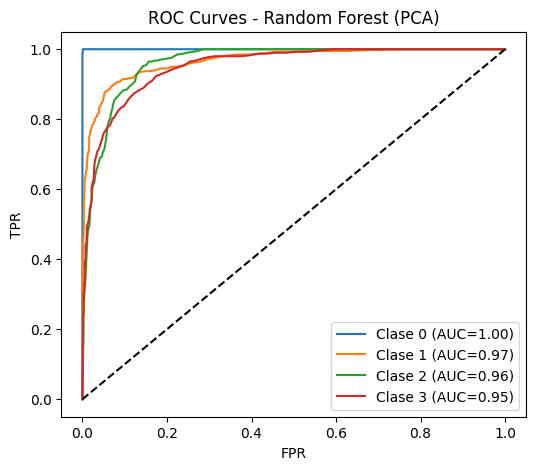


=== SVM (PCA) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       400
           1       0.71      0.58      0.64       400
           2       0.48      0.92      0.63       400
           3       0.55      0.16      0.25       400

    accuracy                           0.66      1600
   macro avg       0.68      0.66      0.63      1600
weighted avg       0.68      0.66      0.63      1600

Confusion Matrix:
[[390   7   0   3]
 [  0 231 131  38]
 [  0  19 368  13]
 [  0  68 267  65]]


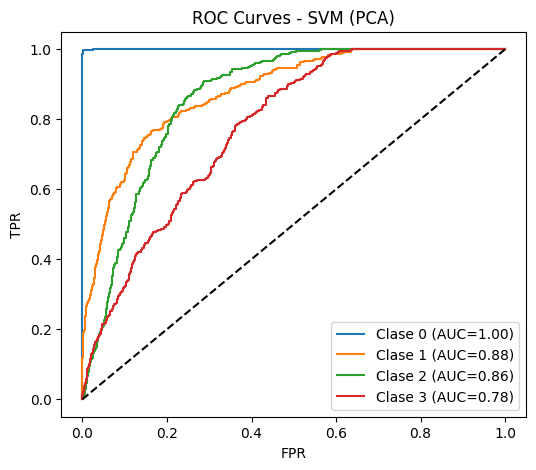


=== Extra Trees (PCA) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.91      0.86      0.89       400
           2       0.78      0.89      0.84       400
           3       0.85      0.78      0.81       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600

Confusion Matrix:
[[398   0   0   2]
 [  0 345  29  26]
 [  0  15 357  28]
 [  0  19  69 312]]


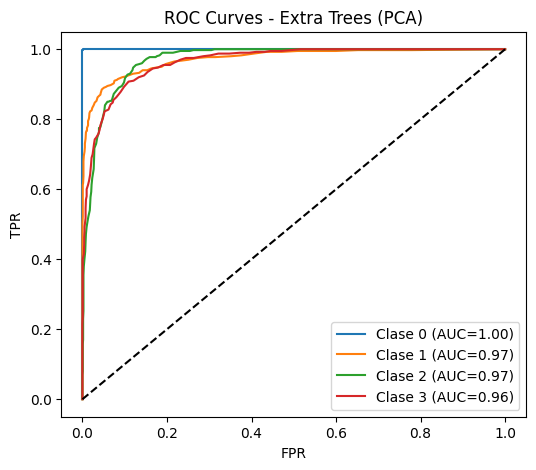

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:22:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost (PCA) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.88      0.85      0.87       400
           2       0.74      0.83      0.78       400
           3       0.79      0.72      0.75       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.85      1600
weighted avg       0.85      0.85      0.85      1600

Confusion Matrix:
[[396   2   0   2]
 [  0 342  33  25]
 [  0  17 333  50]
 [  0  29  83 288]]


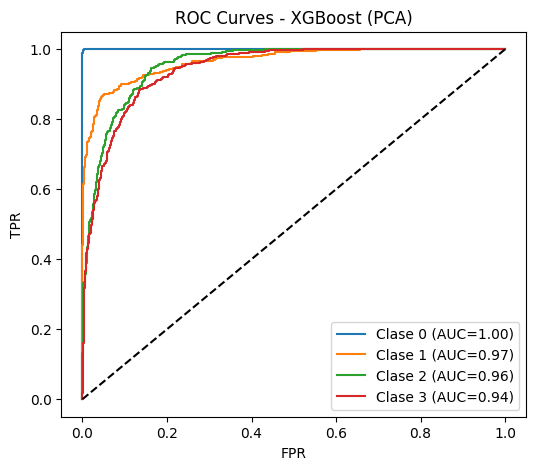


=== MLP (PCA) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.84      0.82      0.83       400
           2       0.73      0.83      0.78       400
           3       0.74      0.66      0.70       400

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.83      1600
weighted avg       0.83      0.83      0.83      1600

Confusion Matrix:
[[398   0   0   2]
 [  0 328  33  39]
 [  0  16 333  51]
 [  0  46  90 264]]


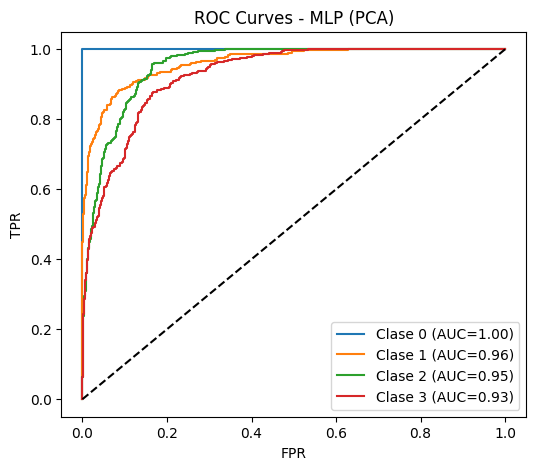

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:23:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Voting Classifier (PCA) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.89      0.85      0.87       400
           2       0.77      0.86      0.81       400
           3       0.80      0.74      0.77       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600

Confusion Matrix:
[[399   0   0   1]
 [  0 342  30  28]
 [  0  13 343  44]
 [  0  29  75 296]]


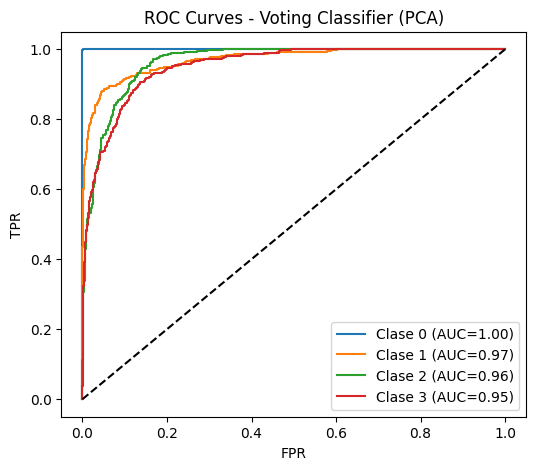


=== Random Forest (UMAP) ===
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.96      0.95      0.96       400
           2       0.92      0.95      0.93       400
           3       0.94      0.92      0.93       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

Confusion Matrix:
[[397   1   0   2]
 [  0 382  10   8]
 [  0   6 379  15]
 [  2   7  23 368]]


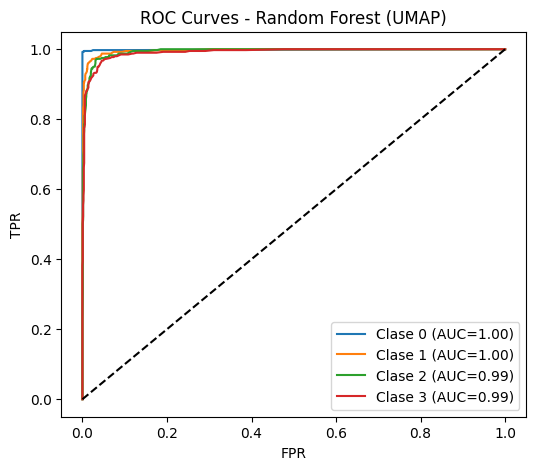


=== SVM (UMAP) ===
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       400
           1       0.80      0.81      0.80       400
           2       0.72      0.86      0.78       400
           3       0.70      0.55      0.61       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.80      1600
weighted avg       0.80      0.80      0.80      1600

Confusion Matrix:
[[399   1   0   0]
 [  0 322  26  52]
 [  0  16 343  41]
 [ 12  65 105 218]]


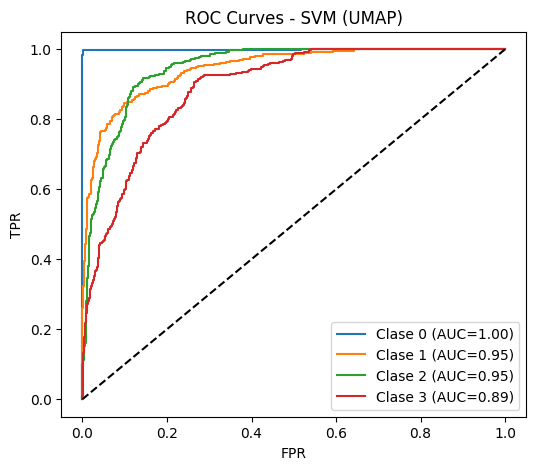


=== Extra Trees (UMAP) ===
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.97      0.96      0.97       400
           2       0.94      0.96      0.95       400
           3       0.95      0.93      0.94       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600

Confusion Matrix:
[[397   2   0   1]
 [  0 386   5   9]
 [  0   5 386   9]
 [  3   4  20 373]]


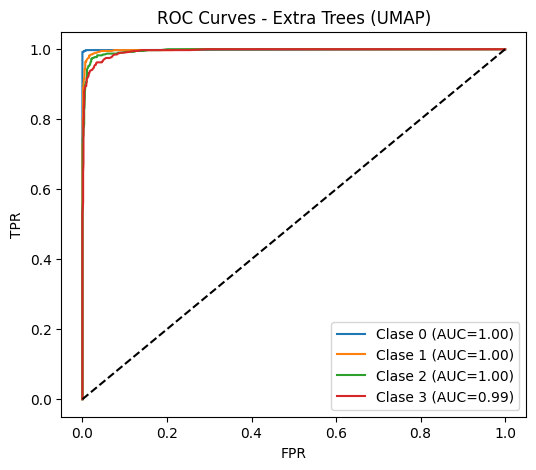

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:23:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost (UMAP) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.96      0.94      0.95       400
           2       0.92      0.94      0.93       400
           3       0.91      0.92      0.92       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

Confusion Matrix:
[[397   1   0   2]
 [  0 375   9  16]
 [  0   7 376  17]
 [  1   9  22 368]]


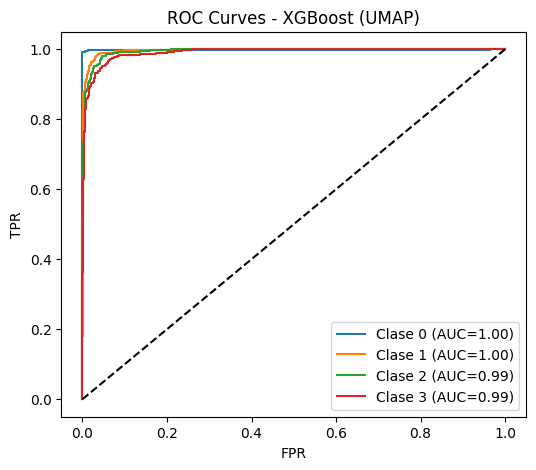


=== MLP (UMAP) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.86      0.84      0.85       400
           2       0.81      0.95      0.88       400
           3       0.87      0.74      0.80       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600

Confusion Matrix:
[[398   1   0   1]
 [  0 338  29  33]
 [  0  10 380  10]
 [  1  43  58 298]]


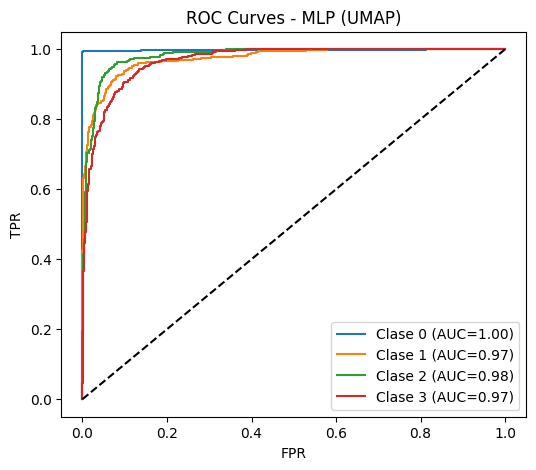

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:24:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Voting Classifier (UMAP) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       400
           1       0.96      0.95      0.95       400
           2       0.91      0.96      0.94       400
           3       0.94      0.91      0.93       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

Confusion Matrix:
[[397   1   0   2]
 [  0 379  11  10]
 [  0   5 385  10]
 [  1  10  25 364]]


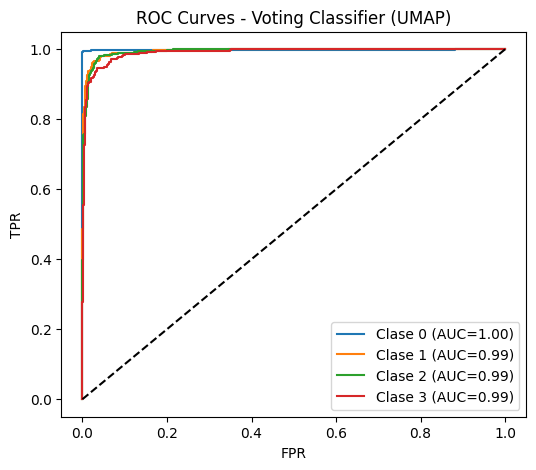

,Modelo,Método,Dimensiones,Reducción (%),Accuracy,Precision,Recall,F1
0,Random Forest,PCA,6,62.5,0.871250,0.872803,0.871250,0.871018
1,Random Forest,UMAP,8,50.0,0.953750,0.953981,0.953750,0.953790
2,SVM,PCA,6,62.5,0.658750,0.684351,0.658750,0.626571
3,SVM,UMAP,8,50.0,0.801250,0.798106,0.801250,0.795771
4,Extra Trees,PCA,6,62.5,0.882500,0.885683,0.882500,0.882708
5,Extra Trees,UMAP,8,50.0,0.963750,0.963874,0.963750,0.963741
6,XGBoost,PCA,6,62.5,0.849375,0.851903,0.849375,0.849548
7,XGBoost,UMAP,8,50.0,0.947500,0.947776,0.947500,0.947592
8,MLP,PCA,6,62.5,0.826875,0.828215,0.826875,0.826081
9,MLP,UMAP,8,50.0,0.883750,0.886197,0.883750,0.882400


In [ ]:
# ---------------------------------------------------------------
# 5️⃣ Entrenamiento y evaluación de todos los modelos
# ---------------------------------------------------------------

results_pca = {}
results_umap = {}

# PCA
for name, model in models.items():
    results_pca[name] = evaluate_model(model, X_train_pca, X_test_pca, y_train_pca, y_test_pca, f"{name} (PCA)")

# UMAP
for name, model in models.items():
    results_umap[name] = evaluate_model(model, X_train_umap, X_test_umap, y_train_umap, y_test_umap, f"{name} (UMAP)")

# ---------------------------------------------------------------
# 6️⃣ Tabla comparativa de desempeño
# ---------------------------------------------------------------

original_dim = X_scaled.shape[1]
summary = []

for name in models.keys():
    summary.append({
        "Modelo": name,
        "Método": "PCA",
        "Dimensiones": X_train_pca.shape[1],
        "Reducción (%)": round((1 - X_train_pca.shape[1]/original_dim)*100,2),
        **results_pca[name]
    })
    summary.append({
        "Modelo": name,
        "Método": "UMAP",
        "Dimensiones": X_train_umap.shape[1],
        "Reducción (%)": round((1 - X_train_umap.shape[1]/original_dim)*100,2),
        **results_umap[name]
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

/tmp/ipython-input-3691161514.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Modelo', y='Valor', hue='Método', data=df_melt, ci=None)


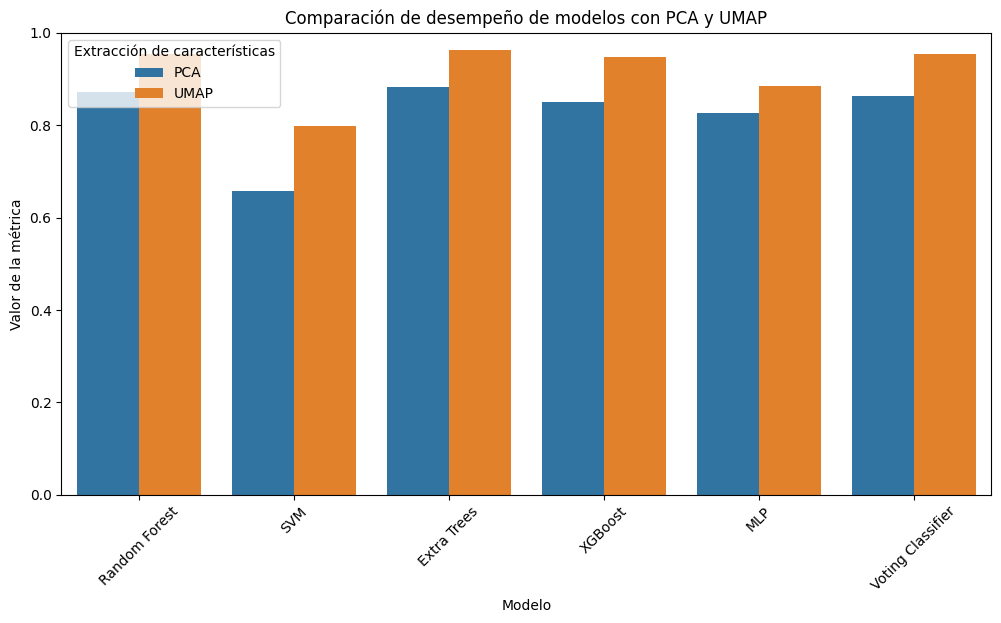

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transformar el DataFrame para plotear métricas
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
df_melt = summary_df.melt(id_vars=['Modelo', 'Método'], value_vars=metrics,
                          var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12,6))
sns.barplot(x='Modelo', y='Valor', hue='Método', data=df_melt, ci=None)
plt.title('Comparación de desempeño de modelos con PCA y UMAP')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.legend(title='Extracción de características')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# ===============================================================
# 🔹 BLOQUE COMPLETO: Entrenamiento y evaluación de modelos
#    Original, PCA y UMAP
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------------------
# 1️⃣ Convertir y a etiquetas enteras si es one-hot
# ---------------------------------------------------------------
if len(y_train.shape) == 2 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_train_labels = y_train
    y_test_labels = y_test

# ---------------------------------------------------------------
# 2️⃣ Definir modelos a entrenar
# ---------------------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, probability=True),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,64), max_iter=300, random_state=42)
}

# Voting Classifier (ensamble)
voting = VotingClassifier(estimators=[
    ('rf', models["Random Forest"]),
    ('et', models["Extra Trees"]),
    ('xgb', models["XGBoost"])
], voting='soft')
models["Voting"] = voting


In [ ]:
# ---------------------------------------------------------------
# 3️⃣ Función para entrenar y evaluar modelos
# ---------------------------------------------------------------
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}

In [ ]:

# ---------------------------------------------------------------
# 4️⃣ Entrenamiento y evaluación con datos originales
# ---------------------------------------------------------------
results_original = {}
original_dim = X_scaled.shape[1]

for name, model in models.items():
    results_original[name] = evaluate_model(model, X_train, X_test, y_train_labels, y_test_labels)

summary_original = []
for name in models.keys():
    summary_original.append({
        "Modelo": name,
        "Método": "Original",
        "Dimensiones": original_dim,
        "Reducción (%)": 0,
        **results_original[name]
    })
summary_original_df = pd.DataFrame(summary_original)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:24:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:25:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# ---------------------------------------------------------------
# 5️⃣ Entrenamiento y evaluación con PCA (6 componentes)
# ---------------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=6, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

results_pca = {}
for name, model in models.items():
    results_pca[name] = evaluate_model(model, X_train_pca, X_test_pca, y_train_labels, y_test_labels)

summary_pca = []
for name in models.keys():
    summary_pca.append({
        "Modelo": name,
        "Método": "PCA",
        "Dimensiones": X_train_pca.shape[1],
        "Reducción (%)": (1 - X_train_pca.shape[1]/original_dim)*100,
        **results_pca[name]
    })
summary_pca_df = pd.DataFrame(summary_pca)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:25:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:25:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:

# ---------------------------------------------------------------
# 6️⃣ Entrenamiento y evaluación con UMAP (8 componentes)
# ---------------------------------------------------------------
import umap

umap_model = umap.UMAP(n_components=8, random_state=42)
X_train_umap = umap_model.fit_transform(X_train)
X_test_umap = umap_model.transform(X_test)

results_umap = {}
for name, model in models.items():
    results_umap[name] = evaluate_model(model, X_train_umap, X_test_umap, y_train_labels, y_test_labels)

summary_umap = []
for name in models.keys():
    summary_umap.append({
        "Modelo": name,
        "Método": "UMAP",
        "Dimensiones": X_train_umap.shape[1],
        "Reducción (%)": (1 - X_train_umap.shape[1]/original_dim)*100,
        **results_umap[name]
    })
summary_umap_df = pd.DataFrame(summary_umap)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:26:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:26:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Modelo,Método,Dimensiones,Reducción (%),Accuracy,Precision,Recall,F1
0,Random Forest,Original,16,0.0,0.953750,0.953981,0.953750,0.953790
1,SVM,Original,16,0.0,0.801250,0.798106,0.801250,0.795771
2,Extra Trees,Original,16,0.0,0.963750,0.963874,0.963750,0.963741
3,XGBoost,Original,16,0.0,0.947500,0.947776,0.947500,0.947592
4,MLP,Original,16,0.0,0.893750,0.895101,0.893750,0.894136
5,Voting,Original,16,0.0,0.955000,0.955118,0.955000,0.955011
6,Random Forest,PCA,6,62.5,0.940625,0.940978,0.940625,0.940579
7,SVM,PCA,6,62.5,0.805000,0.802645,0.805000,0.802625
8,Extra Trees,PCA,6,62.5,0.945000,0.945141,0.945000,0.944959
9,XGBoost,PCA,6,62.5,0.936875,0.937402,0.936875,0.936858


/tmp/ipython-input-189730733.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Modelo', y='Valor', hue='Método', data=df_melt, ci=None)


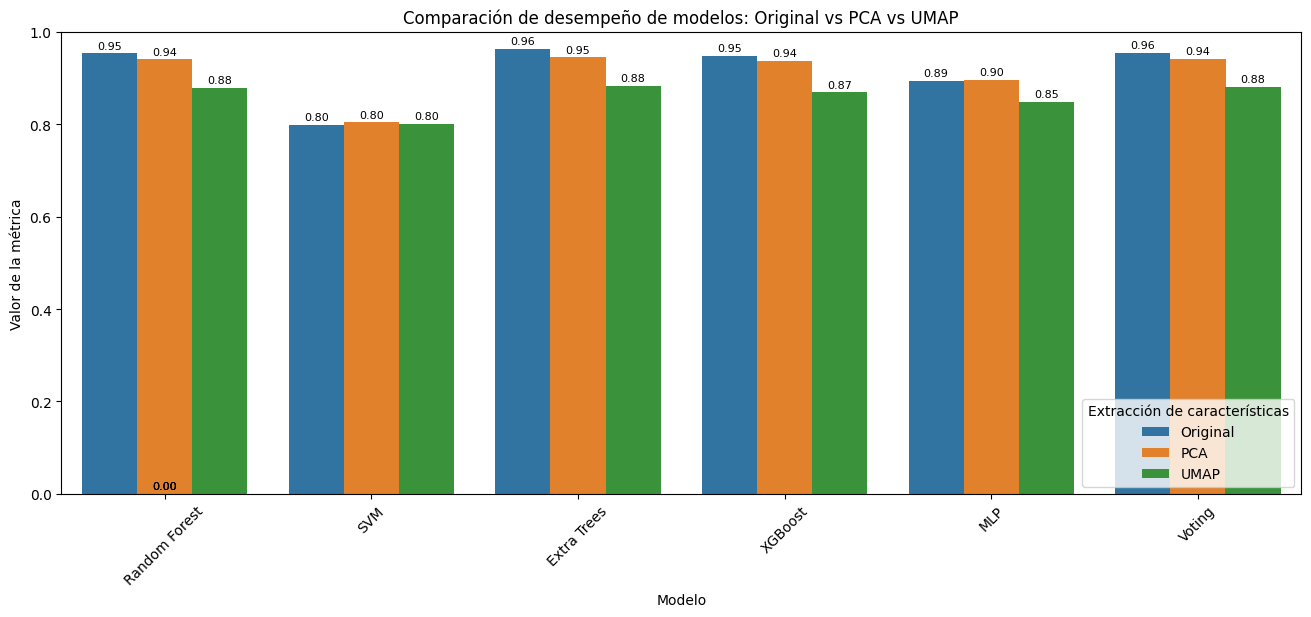

In [ ]:

# ---------------------------------------------------------------
# 7️⃣ Combinar todos los resultados
# ---------------------------------------------------------------
summary_df = pd.concat([summary_original_df, summary_pca_df, summary_umap_df], ignore_index=True)
display(summary_df)

# ---------------------------------------------------------------
# 8️⃣ Gráfico comparativo de desempeño
# ---------------------------------------------------------------
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
df_melt = summary_df.melt(id_vars=['Modelo', 'Método'], value_vars=metrics,
                          var_name='Métrica', value_name='Valor')

plt.figure(figsize=(16,6))
sns.barplot(x='Modelo', y='Valor', hue='Método', data=df_melt, ci=None)
plt.title('Comparación de desempeño de modelos: Original vs PCA vs UMAP')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.legend(title='Extracción de características')
plt.xticks(rotation=45)

# Mostrar valores encima de cada barra
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2., height + 0.01, f'{height:.2f}', ha="center", fontsize=8)

plt.show()

In [ ]:
# ===============================================================
# 🔹 RESUMEN AUTOMÁTICO DE LOS MEJORES MODELOS
# ===============================================================

# Seleccionamos la métrica principal para definir "mejor" modelo
main_metric = 'Accuracy'

# Crear DataFrame resumido de los mejores modelos por método
best_models_summary = []

for method in summary_df['Método'].unique():
    df_method = summary_df[summary_df['Método'] == method]
    best_idx = df_method[main_metric].idxmax()
    best_row = df_method.loc[best_idx]

    best_models_summary.append({
        "Método": best_row['Método'],
        "Modelo": best_row['Modelo'],
        "Dimensiones": best_row['Dimensiones'],
        "Reducción (%)": best_row['Reducción (%)'],
        "Accuracy": best_row['Accuracy'],
        "Precision": best_row['Precision'],
        "Recall": best_row['Recall'],
        "F1": best_row['F1']
    })

best_models_df = pd.DataFrame(best_models_summary)
display(best_models_df)


,Método,Modelo,Dimensiones,Reducción (%),Accuracy,Precision,Recall,F1
0,Original,Extra Trees,16,0.0,0.96375,0.963874,0.96375,0.963741
1,PCA,Extra Trees,6,62.5,0.94500,0.945141,0.94500,0.944959
2,UMAP,Extra Trees,8,50.0,0.88250,0.883093,0.88250,0.882358


In [ ]:
# ===============================================================
# 🔹 RESUMEN COMPLETO DE TODOS LOS MODELOS POR MÉTODO
# ===============================================================
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convertir y_train y y_test a etiquetas 1D si están en one-hot
if y_train.ndim == 2 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_train_labels = y_train
    y_test_labels = y_test

# Lista para almacenar resultados
all_models_summary = []

# Diccionario de métodos y sus datos
methods_data = {
    'Original': (X_train, X_test, X_train.shape[1], 0),
    'PCA': (X_train_pca, X_test_pca, X_train_pca.shape[1], round(100*(1 - X_train_pca.shape[1]/X_train.shape[1]),1)),
    'UMAP': (X_train_umap, X_test_umap, X_train_umap.shape[1], round(100*(1 - X_train_umap.shape[1]/X_train.shape[1]),1))
}

# Entrenar y evaluar todos los modelos
for name, model in models.items():
    for method, (X_tr, X_te, dims, red_pct) in methods_data.items():
        model.fit(X_tr, y_train_labels)
        y_pred = model.predict(X_te)

        # Calcular métricas
        acc = accuracy_score(y_test_labels, y_pred)
        prec = precision_score(y_test_labels, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test_labels, y_pred, average='weighted')
        f1 = f1_score(y_test_labels, y_pred, average='weighted')

        all_models_summary.append({
            'Modelo': name,
            'Método': method,
            'Dimensiones': dims,
            'Reducción (%)': red_pct,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

# Convertir a DataFrame
all_models_df = pd.DataFrame(all_models_summary)
display(all_models_df)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:27:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:27:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:27:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:28:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:28:42] WARNING: /w

,Modelo,Método,Dimensiones,Reducción (%),Accuracy,Precision,Recall,F1
0,Random Forest,Original,8,0.0,0.953750,0.953981,0.953750,0.953790
1,Random Forest,PCA,6,25.0,0.940625,0.940978,0.940625,0.940579
2,Random Forest,UMAP,8,0.0,0.878750,0.880197,0.878750,0.878809
3,SVM,Original,8,0.0,0.801250,0.798106,0.801250,0.795771
4,SVM,PCA,6,25.0,0.805000,0.802645,0.805000,0.802625
5,SVM,UMAP,8,0.0,0.799375,0.805243,0.799375,0.798930
6,Extra Trees,Original,8,0.0,0.963750,0.963874,0.963750,0.963741
7,Extra Trees,PCA,6,25.0,0.945000,0.945141,0.945000,0.944959
8,Extra Trees,UMAP,8,0.0,0.882500,0.883093,0.882500,0.882358
9,XGBoost,Original,8,0.0,0.947500,0.947776,0.947500,0.947592


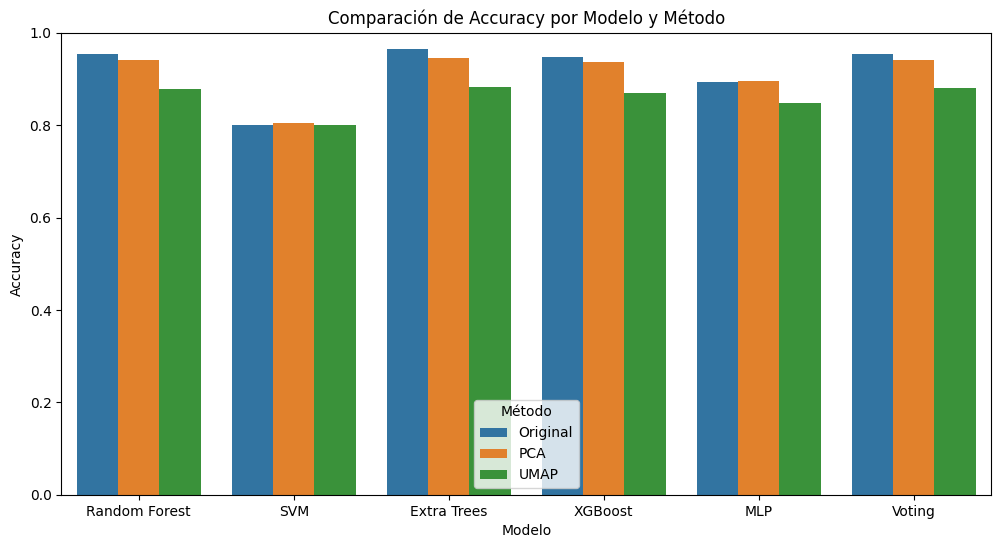

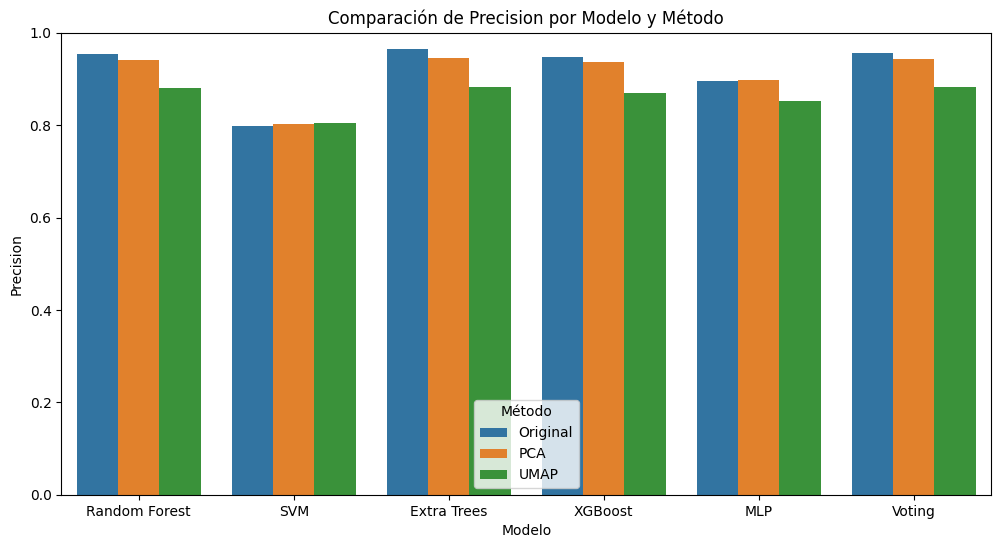

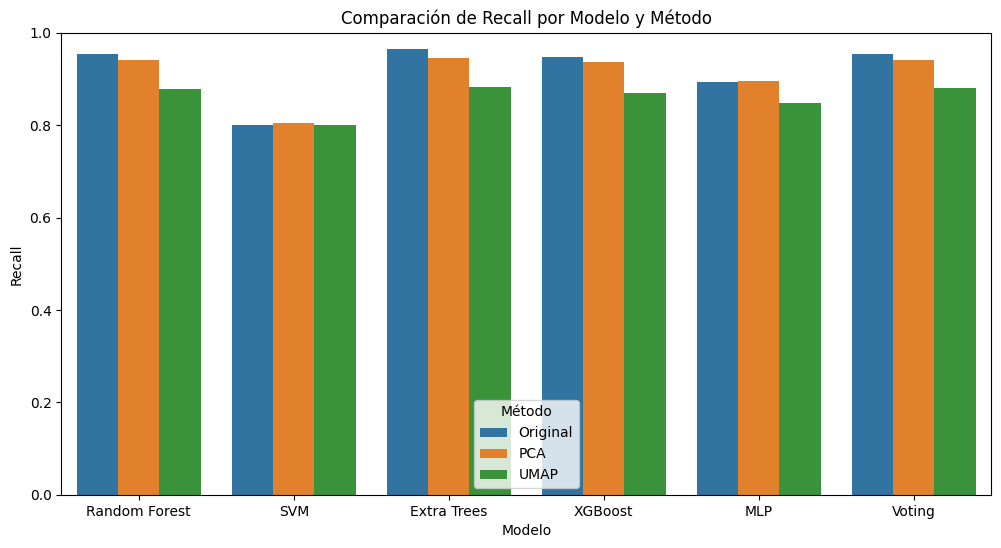

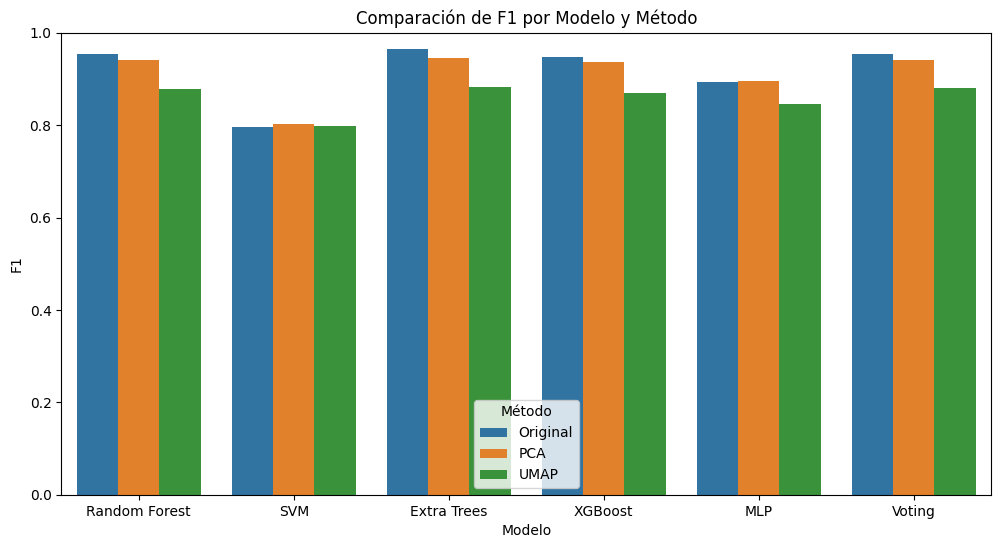

In [ ]:

# ===============================================================
# 🔹 GRÁFICO COMPARATIVO DE BARRAS POR MÉTRICA
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['Accuracy','Precision','Recall','F1']

for metric in metrics:
    plt.figure(figsize=(12,6))
    sns.barplot(x='Modelo', y=metric, hue='Método', data=all_models_df)
    plt.title(f'Comparación de {metric} por Modelo y Método')
    plt.ylabel(metric)
    plt.ylim(0,1)
    plt.legend(title='Método')
    plt.show()

In [ ]:
# ===============================================================
# 🔹 COMPARACIÓN DE MODELOS CON DATOS ORIGINALES
# ===============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convertir y_train y y_test a etiquetas 1D si están en one-hot
if y_train.ndim == 2 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_train_labels = y_train
    y_test_labels = y_test

# Lista para almacenar resultados
original_models_summary = []

# Entrenar y evaluar modelos con datos originales
for name, model in models.items():
    model.fit(X_train, y_train_labels)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test_labels, y_pred)
    prec = precision_score(y_test_labels, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_labels, y_pred, average='weighted')
    f1 = f1_score(y_test_labels, y_pred, average='weighted')

    original_models_summary.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

# Convertir a DataFrame
original_models_df = pd.DataFrame(original_models_summary)
display(original_models_df)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:28:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:29:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Modelo,Accuracy,Precision,Recall,F1
0,Random Forest,0.95375,0.953981,0.95375,0.953790
1,SVM,0.80125,0.798106,0.80125,0.795771
2,Extra Trees,0.96375,0.963874,0.96375,0.963741
3,XGBoost,0.94750,0.947776,0.94750,0.947592
4,MLP,0.89375,0.895101,0.89375,0.894136
5,Voting,0.95500,0.955118,0.95500,0.955011


/tmp/ipython-input-4215474196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metric, data=original_models_df, palette='Set2')


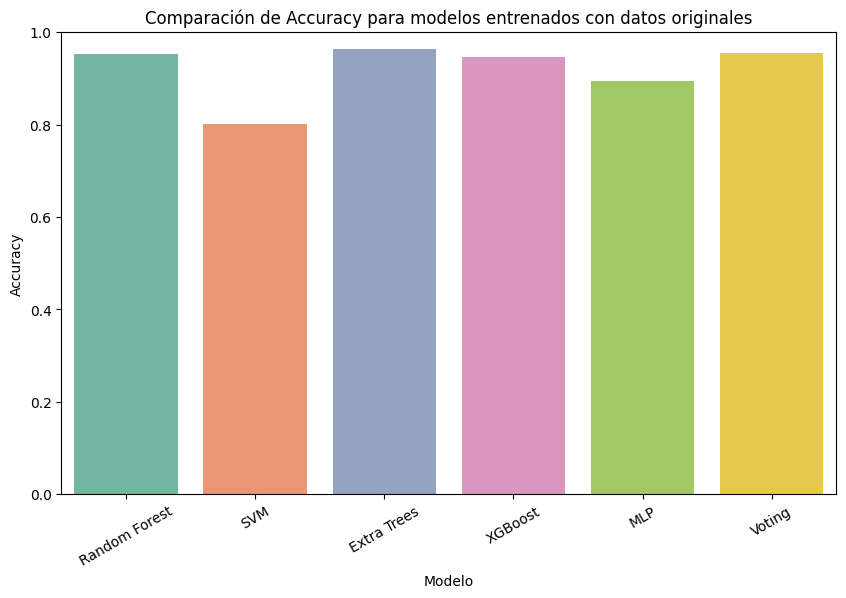

/tmp/ipython-input-4215474196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metric, data=original_models_df, palette='Set2')


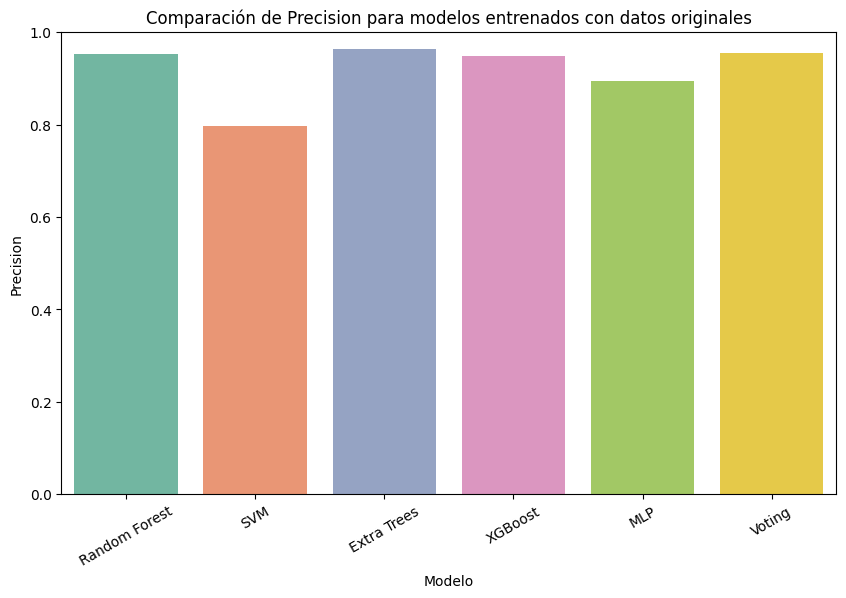

/tmp/ipython-input-4215474196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metric, data=original_models_df, palette='Set2')


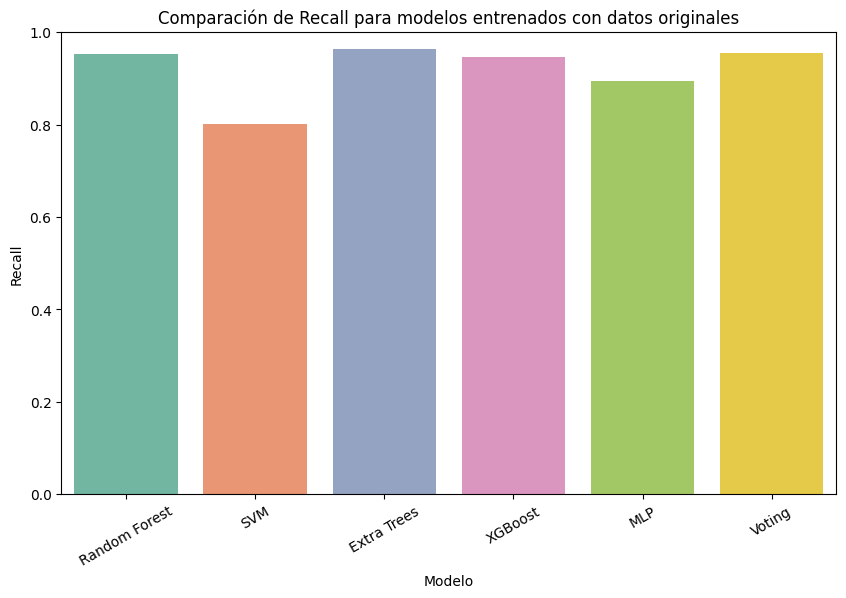

/tmp/ipython-input-4215474196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metric, data=original_models_df, palette='Set2')


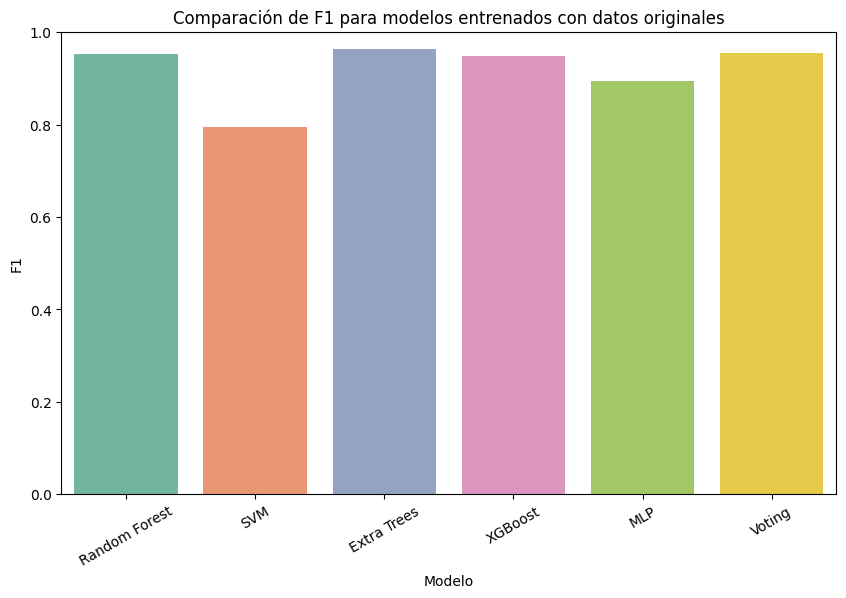

In [ ]:
# ===============================================================
# 🔹 GRÁFICO DE BARRAS COMPARANDO LOS MODELOS
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['Accuracy','Precision','Recall','F1']

for metric in metrics:
    plt.figure(figsize=(10,6))
    sns.barplot(x='Modelo', y=metric, data=original_models_df, palette='Set2')
    plt.title(f'Comparación de {metric} para modelos entrenados con datos originales')
    plt.ylabel(metric)
    plt.ylim(0,1)
    plt.xticks(rotation=30)
    plt.show()